# Análise RS — Frutas

Notebook gerado no mesmo padrão das análises anteriores, usando o arquivo `data_RS_Frutas.xlsx`.

Gráficos finais incluídos:
1. Evolução do peso exportado por Porto/URF
2. Evolução dos 3 maiores Portos/URFs
3. Participação percentual por URF no total exportado de Frutas (2015–2025)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display

arquivo = "data_RS_Frutas.xlsx"
abas = pd.read_excel(arquivo, sheet_name=None)

nomes_portos = {
    "1010252": "1010252 - Jaguarão",
    "1010253": "1010253 - Bagé",
    "1010351": "1010351 - IRF Santana do Livramento",
    "1010900": "1010900 - Uruguaiana",
    "1010953": "1010953 - São Borja",
    "1015500": "1015500 - Chuí",
    "1015600": "1015600 - Santana do Livramento",
    "1017500": "1017500 - ALF Uruguaiana",
    "1017503": "1017503 - IRF São Borja",
    "1017600": "1017600 - Aeroporto Salgado Filho",
    "1017700": "1017700 - Porto de Rio Grande",
    "1017701": "1017701 - IRF Chuí",
    "1017800": "1017800 - ALF Porto Alegre",
    "1017801": "1017801 - IRF Aeroporto Salgado Filho",
    "1017900": "1017900 - ALF Santana do Livramento"
}

lista_dfs = []

for nome_aba, df in abas.items():
    df = df.copy()

    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df["Porto_URF"] = nomes_portos.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs.append(df)

base = pd.concat(lista_dfs, ignore_index=True)

base["Peso_KG"] = pd.to_numeric(base["Peso_KG"], errors="coerce").fillna(0)
base["Valor_USD"] = pd.to_numeric(base["Valor_USD"], errors="coerce").fillna(0)

base.head()

,Agrupamento,Transacao,Ano,Produto,Regiao_UF_URF,Valor_USD,Peso_KG,Tipo_Local,Local,Porto_URF
0,Acordo Agrícola OMC e Pescados,Exportacao,2015,(1º Nível) FRUTAS (INCLUI NOZES E CASTANHAS),(URF) 1010252 - JAGUARAO,7486720.0,26585976.0,URF,1010252 - JAGUARAO,1010252 - Jaguarão
1,Acordo Agrícola OMC e Pescados,Exportacao,2016,(1º Nível) FRUTAS (INCLUI NOZES E CASTANHAS),(URF) 1010252 - JAGUARAO,7958676.0,20838772.0,URF,1010252 - JAGUARAO,1010252 - Jaguarão
2,Acordo Agrícola OMC e Pescados,Exportacao,2017,(1º Nível) FRUTAS (INCLUI NOZES E CASTANHAS),(URF) 1010252 - JAGUARAO,6267270.0,16215164.0,URF,1010252 - JAGUARAO,1010252 - Jaguarão
3,Acordo Agrícola OMC e Pescados,Exportacao,2018,(1º Nível) FRUTAS (INCLUI NOZES E CASTANHAS),(URF) 1010252 - JAGUARAO,7060335.0,21546818.0,URF,1010252 - JAGUARAO,1010252 - Jaguarão
4,Acordo Agrícola OMC e Pescados,Exportacao,2019,(1º Nível) FRUTAS (INCLUI NOZES E CASTANHAS),(URF) 1010252 - JAGUARAO,7629204.0,22907511.0,URF,1010252 - JAGUARAO,1010252 - Jaguarão


In [2]:
df_porto_ano = (
    base
    .groupby(["Ano", "Porto_URF"], as_index=False)["Peso_KG"]
    .sum()
)

df_porto_ano["Peso_milhoes"] = df_porto_ano["Peso_KG"] / 1_000_000

total_por_porto = (
    df_porto_ano
    .groupby("Porto_URF", as_index=False)["Peso_KG"]
    .sum()
    .sort_values("Peso_KG", ascending=False)
)

total_por_porto["Participacao_%"] = total_por_porto["Peso_KG"] / total_por_porto["Peso_KG"].sum() * 100

display(total_por_porto)

,Porto_URF,Peso_KG,Participacao_%
0,1010252 - Jaguarão,630618938.0,66.308827
10,1017700 - Porto de Rio Grande,94834094.0,9.971692
11,1017701 - IRF Chuí,56920142.0,5.985085
6,1015600 - Santana do Livramento,53439762.0,5.619127
14,1017900 - ALF Santana do Livramento,45093052.0,4.741480
8,1017503 - IRF São Borja,27368042.0,2.877717
5,1015500 - Chuí,14534120.0,1.528245
2,1010351 - IRF Santana do Livramento,11911246.0,1.252453
7,1017500 - ALF Uruguaiana,9469512.0,0.995708
3,1010900 - Uruguaiana,5560244.0,0.584653


## 1. Evolução do peso exportado de Frutas por Porto/URF

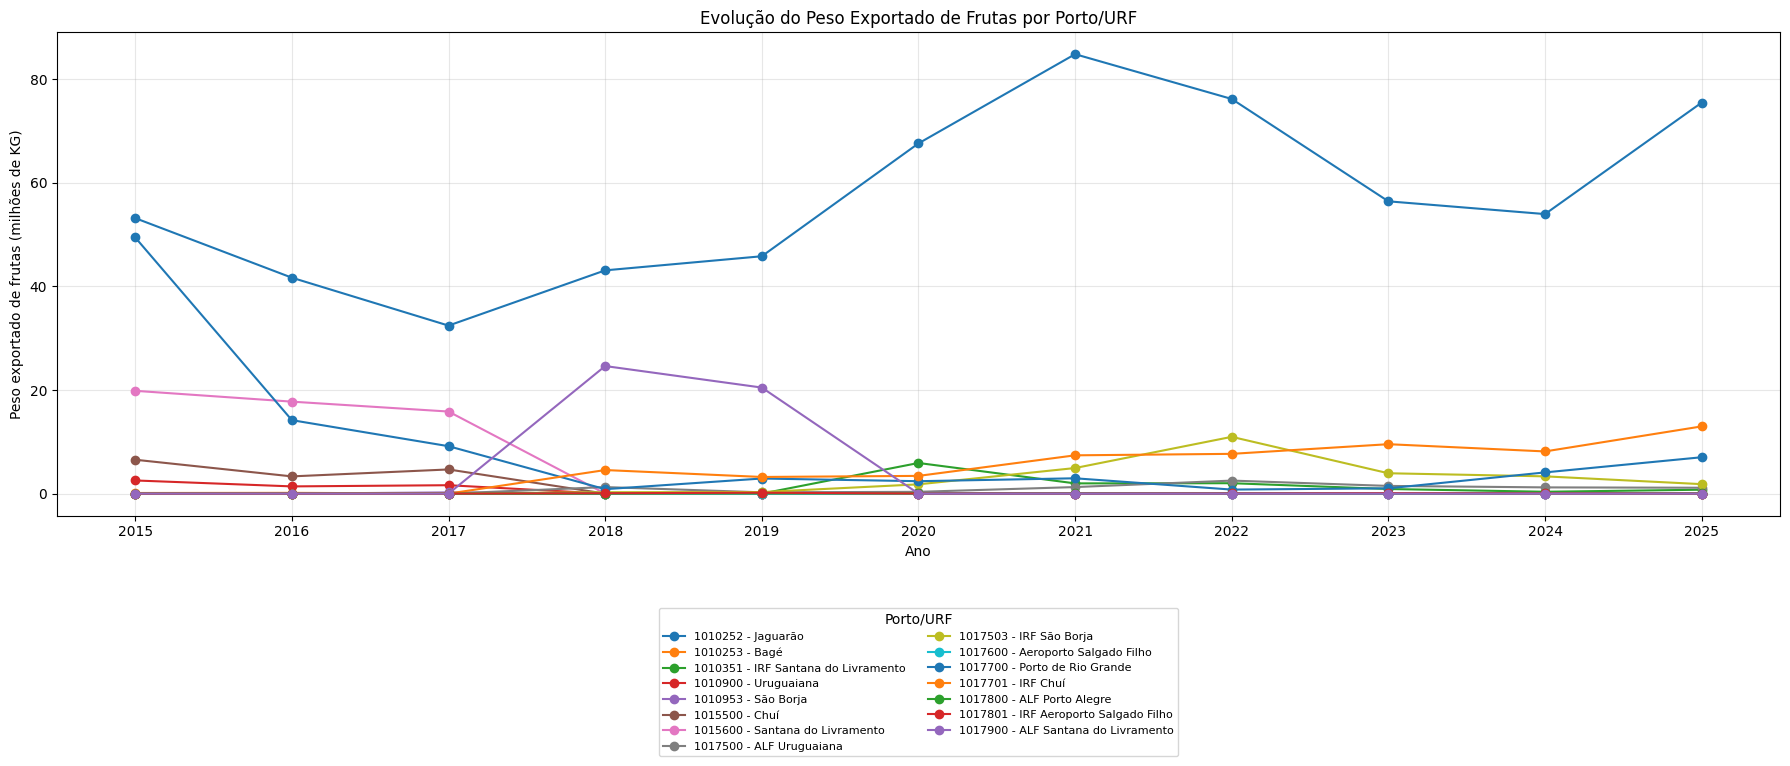

In [3]:
grafico = df_porto_ano.copy()

tabela_grafico = grafico.pivot(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes"
).fillna(0)

plt.figure(figsize=(18, 8))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        label=porto
    )

plt.title("Evolução do Peso Exportado de Frutas por Porto/URF")
plt.xlabel("Ano")
plt.ylabel("Peso exportado de frutas (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Evolução dos 3 maiores Portos/URFs

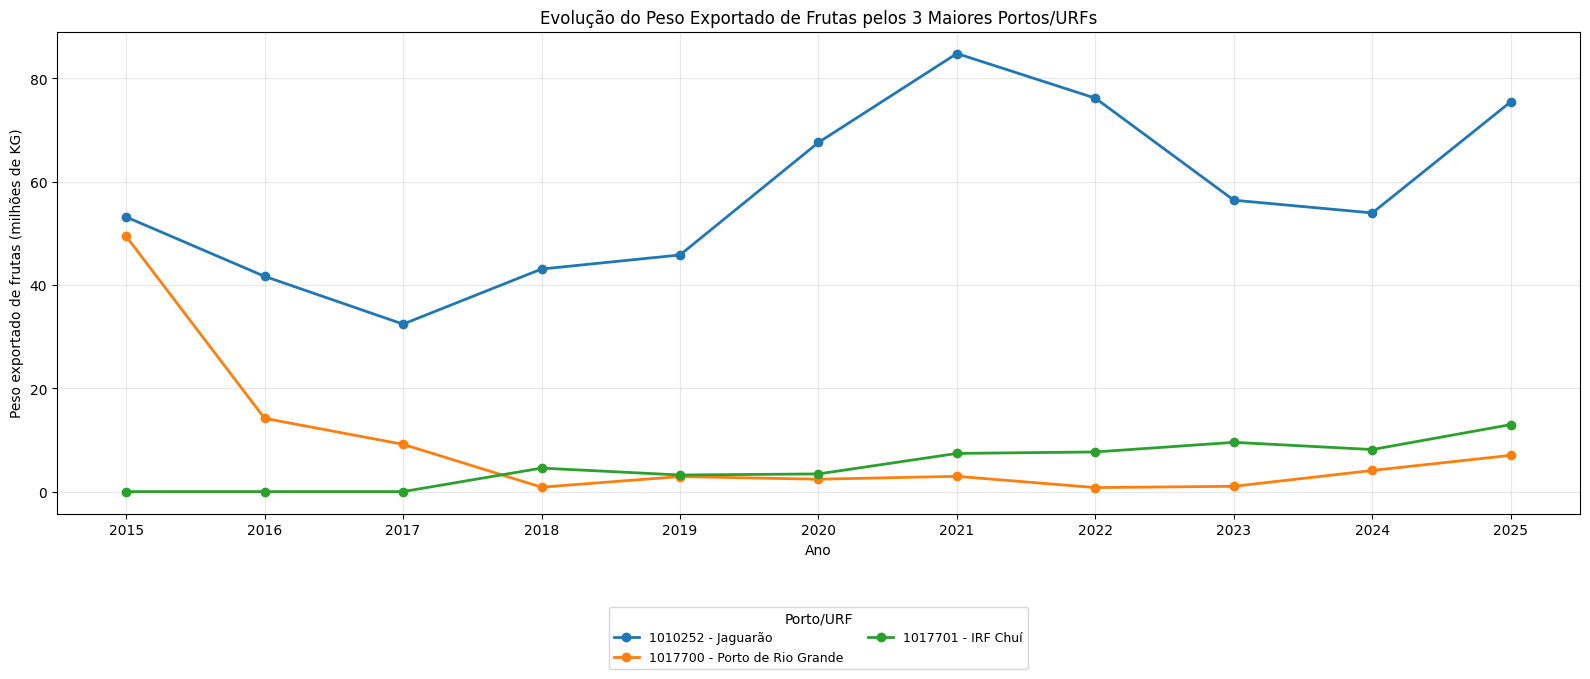

In [4]:
grafico = df_porto_ano.copy()

# Identificar os 3 maiores exportadores no total do período
top3_portos = (
    grafico
    .groupby("Porto_URF")["Peso_milhoes"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# Filtrar apenas o Top 3
grafico_top3 = grafico[grafico["Porto_URF"].isin(top3_portos)]

# Criar tabela para o gráfico
tabela_grafico = grafico_top3.pivot_table(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 7))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        linewidth=2,
        label=porto
    )

plt.title("Evolução do Peso Exportado de Frutas pelos 3 Maiores Portos/URFs")
plt.xlabel("Ano")
plt.ylabel("Peso exportado de frutas (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=9
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Participação percentual por URF no total exportado

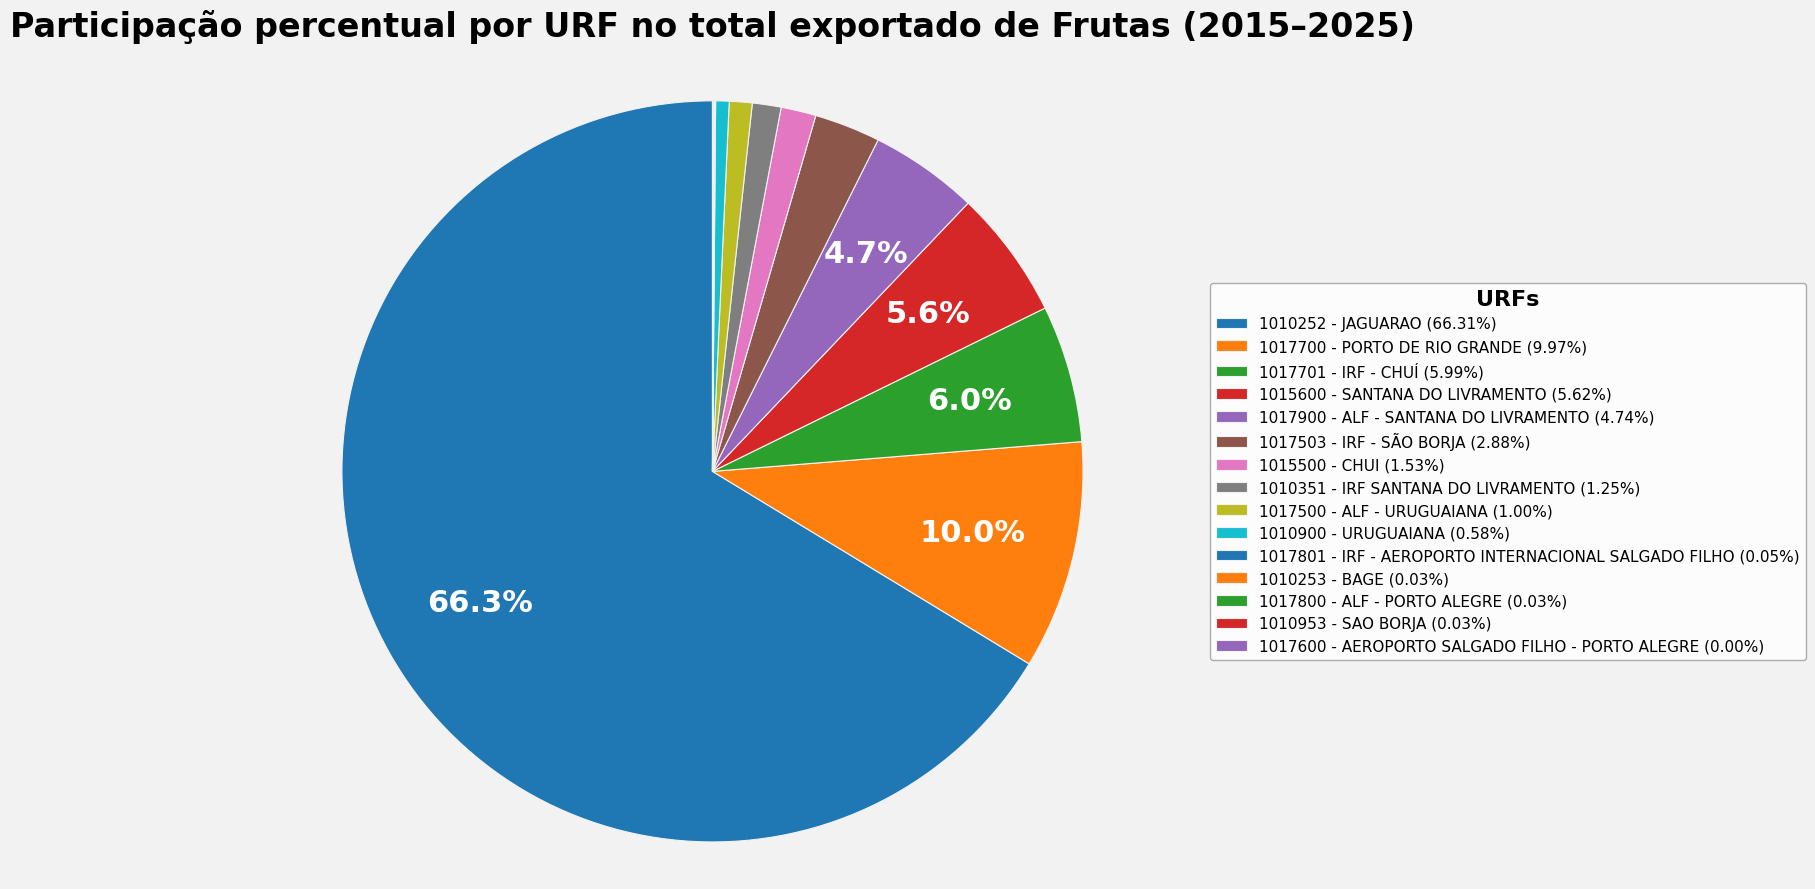

,Porto_URF,Peso_KG,Participacao_%
0,1010252 - JAGUARAO,630618938.0,66.308827
10,1017700 - PORTO DE RIO GRANDE,94834094.0,9.971692
11,1017701 - IRF - CHUÍ,56920142.0,5.985085
6,1015600 - SANTANA DO LIVRAMENTO,53439762.0,5.619127
14,1017900 - ALF - SANTANA DO LIVRAMENTO,45093052.0,4.741480
8,1017503 - IRF - SÃO BORJA,27368042.0,2.877717
5,1015500 - CHUI,14534120.0,1.528245
2,1010351 - IRF SANTANA DO LIVRAMENTO,11911246.0,1.252453
7,1017500 - ALF - URUGUAIANA,9469512.0,0.995708
3,1010900 - URUGUAIANA,5560244.0,0.584653


In [5]:
# Gráfico adicional de participação percentual por URF no total exportado

nomes_portos_legenda = {
    "1010252": "1010252 - JAGUARAO",
    "1010253": "1010253 - BAGE",
    "1010351": "1010351 - IRF SANTANA DO LIVRAMENTO",
    "1010900": "1010900 - URUGUAIANA",
    "1010953": "1010953 - SAO BORJA",
    "1015500": "1015500 - CHUI",
    "1015600": "1015600 - SANTANA DO LIVRAMENTO",
    "1017500": "1017500 - ALF - URUGUAIANA",
    "1017503": "1017503 - IRF - SÃO BORJA",
    "1017600": "1017600 - AEROPORTO SALGADO FILHO - PORTO ALEGRE",
    "1017700": "1017700 - PORTO DE RIO GRANDE",
    "1017701": "1017701 - IRF - CHUÍ",
    "1017800": "1017800 - ALF - PORTO ALEGRE",
    "1017801": "1017801 - IRF - AEROPORTO INTERNACIONAL SALGADO FILHO",
    "1017900": "1017900 - ALF - SANTANA DO LIVRAMENTO"
}

lista_dfs_pizza = []
for nome_aba, df in abas.items():
    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df = df.copy()
        df["Porto_URF"] = nomes_portos_legenda.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs_pizza.append(df)

base_pizza = pd.concat(lista_dfs_pizza, ignore_index=True)
base_pizza["Peso_KG"] = pd.to_numeric(base_pizza["Peso_KG"], errors="coerce").fillna(0)

participacao = (
    base_pizza
    .groupby("Porto_URF", as_index=False)["Peso_KG"]
    .sum()
    .sort_values("Peso_KG", ascending=False)
)
participacao["Participacao_%"] = participacao["Peso_KG"] / participacao["Peso_KG"].sum() * 100

valores = participacao["Peso_KG"].tolist()
legendas = [
    f"{linha['Porto_URF']} ({linha['Participacao_%']:.2f}%)"
    for _, linha in participacao.iterrows()
]

plt.figure(figsize=(16, 9), facecolor="#f2f2f2")
ax = plt.gca()
ax.set_facecolor("#f2f2f2")

def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= 4 else ""

wedges, texts, autotexts = plt.pie(
    valores,
    startangle=90,
    autopct=autopct_func,
    pctdistance=0.72,
    textprops={"color": "white", "fontsize": 18, "fontweight": "bold"},
    wedgeprops={"linewidth": 0.8, "edgecolor": "#f2f2f2"}
)

for texto in autotexts:
    texto.set_fontsize(22)
    texto.set_fontweight("bold")
    texto.set_color("white")

plt.title(
    "Participação percentual por URF no total exportado de Frutas (2015–2025)",
    fontsize=24,
    fontweight="bold",
    pad=20
)

leg = plt.legend(
    wedges,
    legendas,
    title="URFs",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=16,
    frameon=True
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("#999999")
leg.get_title().set_fontweight("bold")

plt.axis("equal")
plt.tight_layout()
plt.savefig("participacao_percentual_urf_frutas.png", dpi=150, bbox_inches="tight", facecolor="#f2f2f2")
plt.show()

participacao